# Chromosome, Replicate 1 Scripting

Create a script to run the deconvolution on each replicate. This notebook will test the script.


In [100]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [101]:
from pipeline.fit_replication_profiles import main
from src.utils import mkdir_safe

output_directory = "output/prototype_pipeline_subset_stage2/"


In [102]:
from pipeline.fit_replication_profiles import main as fit_replication_profile
from src.utils import print_fl
from src.config import load_default_chrom_configs
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.optimize_H import create_bounds_params_from_config

cold_start = False
chrom = 4
replicate = 1
num_epochs = 1
config = None
deconvolve_stage = 2

np.random.seed(123)

update_params_df, replication_deconvolver, optimizer = fit_replication_profile(chrom=chrom, 
    replicate=replicate, num_epochs=100, output_directory=output_directory, 
    deconvolve_stage=2, save=False)


Deconvolve stage:  2
Loading initial cell cycle parameters from CLOCCS fits.
Shifting mu0, gamma1, and gamma2, for alpha...
Omit windows with less than 75% read coverage.
Running initial iterations...
Warm start config, N, F, and B from directory: output/prototype_pipeline_subset_stage2/
Deconvolving 702 regions
Initializing B using timepoint 0
No subset, full parameter updates
** todo: testing learning only delta and lambda **
[0] 00:00:00.339, rn=1.1116836932478817
[1] 00:00:00.687, rn=0.006326133461334883
[2] 00:00:01.111, rn=0.00583422513708287
[3] 00:00:01.539, rn=0.005354293251821002
[4] 00:00:01.890, rn=0.004905544144475561
[5] 00:00:02.240, rn=0.00451598607149126
[6] 00:00:02.598, rn=0.00418615254250576
[7] 00:00:02.953, rn=0.003919207320718416
[8] 00:00:03.303, rn=0.0037091354726334616
[9] 00:00:03.657, rn=0.0035554011271451513
[10] 00:00:04.011, rn=0.0034441310064499313
[11] 00:00:04.374, rn=0.003365601190747188
[12] 00:00:04.725, rn=0.0033147550316953932
[13] 00:00:05.087, r

00:08:50.397
delta          1.357666
lambda        68.806231
opt_H_loss     0.003145
F_rn           0.003145
Name: 20, dtype: float64
Epoch: 21
Optimization [1]: Current loss: 0.003145054109765319
Optimization terminated successfully.
         Current function value: 0.003145
         Iterations: 41
         Function evaluations: 78
00:09:14.889
delta          1.354098
lambda        68.806913
opt_H_loss     0.003145
F_rn           0.003145
Name: 21, dtype: float64
Epoch: 22
Optimization [1]: Current loss: 0.003145033273797832
Optimization terminated successfully.
         Current function value: 0.003145
         Iterations: 37
         Function evaluations: 75
00:09:38.484
delta          1.351382
lambda        68.807462
opt_H_loss     0.003145
F_rn           0.003145
Name: 22, dtype: float64
Epoch: 23
Optimization [1]: Current loss: 0.0031450159612998615
Optimization terminated successfully.
         Current function value: 0.003145
         Iterations: 38
         Function evaluation

Optimization [1]: Current loss: 0.0031449312281964384
Optimization terminated successfully.
         Current function value: 0.003145
         Iterations: 34
         Function evaluations: 69
00:18:53.048
delta          1.342193
lambda        68.809869
opt_H_loss     0.003145
F_rn           0.003145
Name: 45, dtype: float64
Epoch: 46
Optimization [1]: Current loss: 0.00314493087952645
Optimization terminated successfully.
         Current function value: 0.003145
         Iterations: 37
         Function evaluations: 74
00:19:17.010
delta          1.342183
lambda        68.809874
opt_H_loss     0.003145
F_rn           0.003145
Name: 46, dtype: float64
Epoch: 47
Optimization [1]: Current loss: 0.003144930665991623
Optimization terminated successfully.
         Current function value: 0.003145
         Iterations: 37
         Function evaluations: 74
00:19:40.676
delta          1.342176
lambda        68.809878
opt_H_loss     0.003145
F_rn           0.003145
Name: 47, dtype: float64
Epoch

00:28:21.851
delta          1.342129
lambda        68.809902
opt_H_loss     0.003145
F_rn           0.003145
Name: 69, dtype: float64
Epoch: 70
Optimization [1]: Current loss: 0.003144929512359559
Optimization terminated successfully.
         Current function value: 0.003145
         Iterations: 35
         Function evaluations: 71
00:28:45.319
delta          1.342137
lambda        68.809901
opt_H_loss     0.003145
F_rn           0.003145
Name: 70, dtype: float64
Epoch: 71
Optimization [1]: Current loss: 0.0031449295276878243
Optimization terminated successfully.
         Current function value: 0.003145
         Iterations: 36
         Function evaluations: 72
00:29:08.919
delta          1.342129
lambda        68.809902
opt_H_loss     0.003145
F_rn           0.003145
Name: 71, dtype: float64
Epoch: 72
Optimization [1]: Current loss: 0.0031449295123597122
Optimization terminated successfully.
         Current function value: 0.003145
         Iterations: 35
         Function evaluatio

Optimization [1]: Current loss: 0.0031449295123613954
Optimization terminated successfully.
         Current function value: 0.003145
         Iterations: 35
         Function evaluations: 71
00:38:04.282
delta          1.342137
lambda        68.809901
opt_H_loss     0.003145
F_rn           0.003145
Name: 94, dtype: float64
Epoch: 95
Optimization [1]: Current loss: 0.003144929527689661
Optimization terminated successfully.
         Current function value: 0.003145
         Iterations: 36
         Function evaluations: 72
00:38:27.679
delta          1.342129
lambda        68.809902
opt_H_loss     0.003145
F_rn           0.003145
Name: 95, dtype: float64
Epoch: 96
Optimization [1]: Current loss: 0.003144929512361548
Optimization terminated successfully.
         Current function value: 0.003145
         Iterations: 35
         Function evaluations: 71
00:38:51.085
delta          1.342137
lambda        68.809901
opt_H_loss     0.003145
F_rn           0.003145
Name: 96, dtype: float64
Epoc

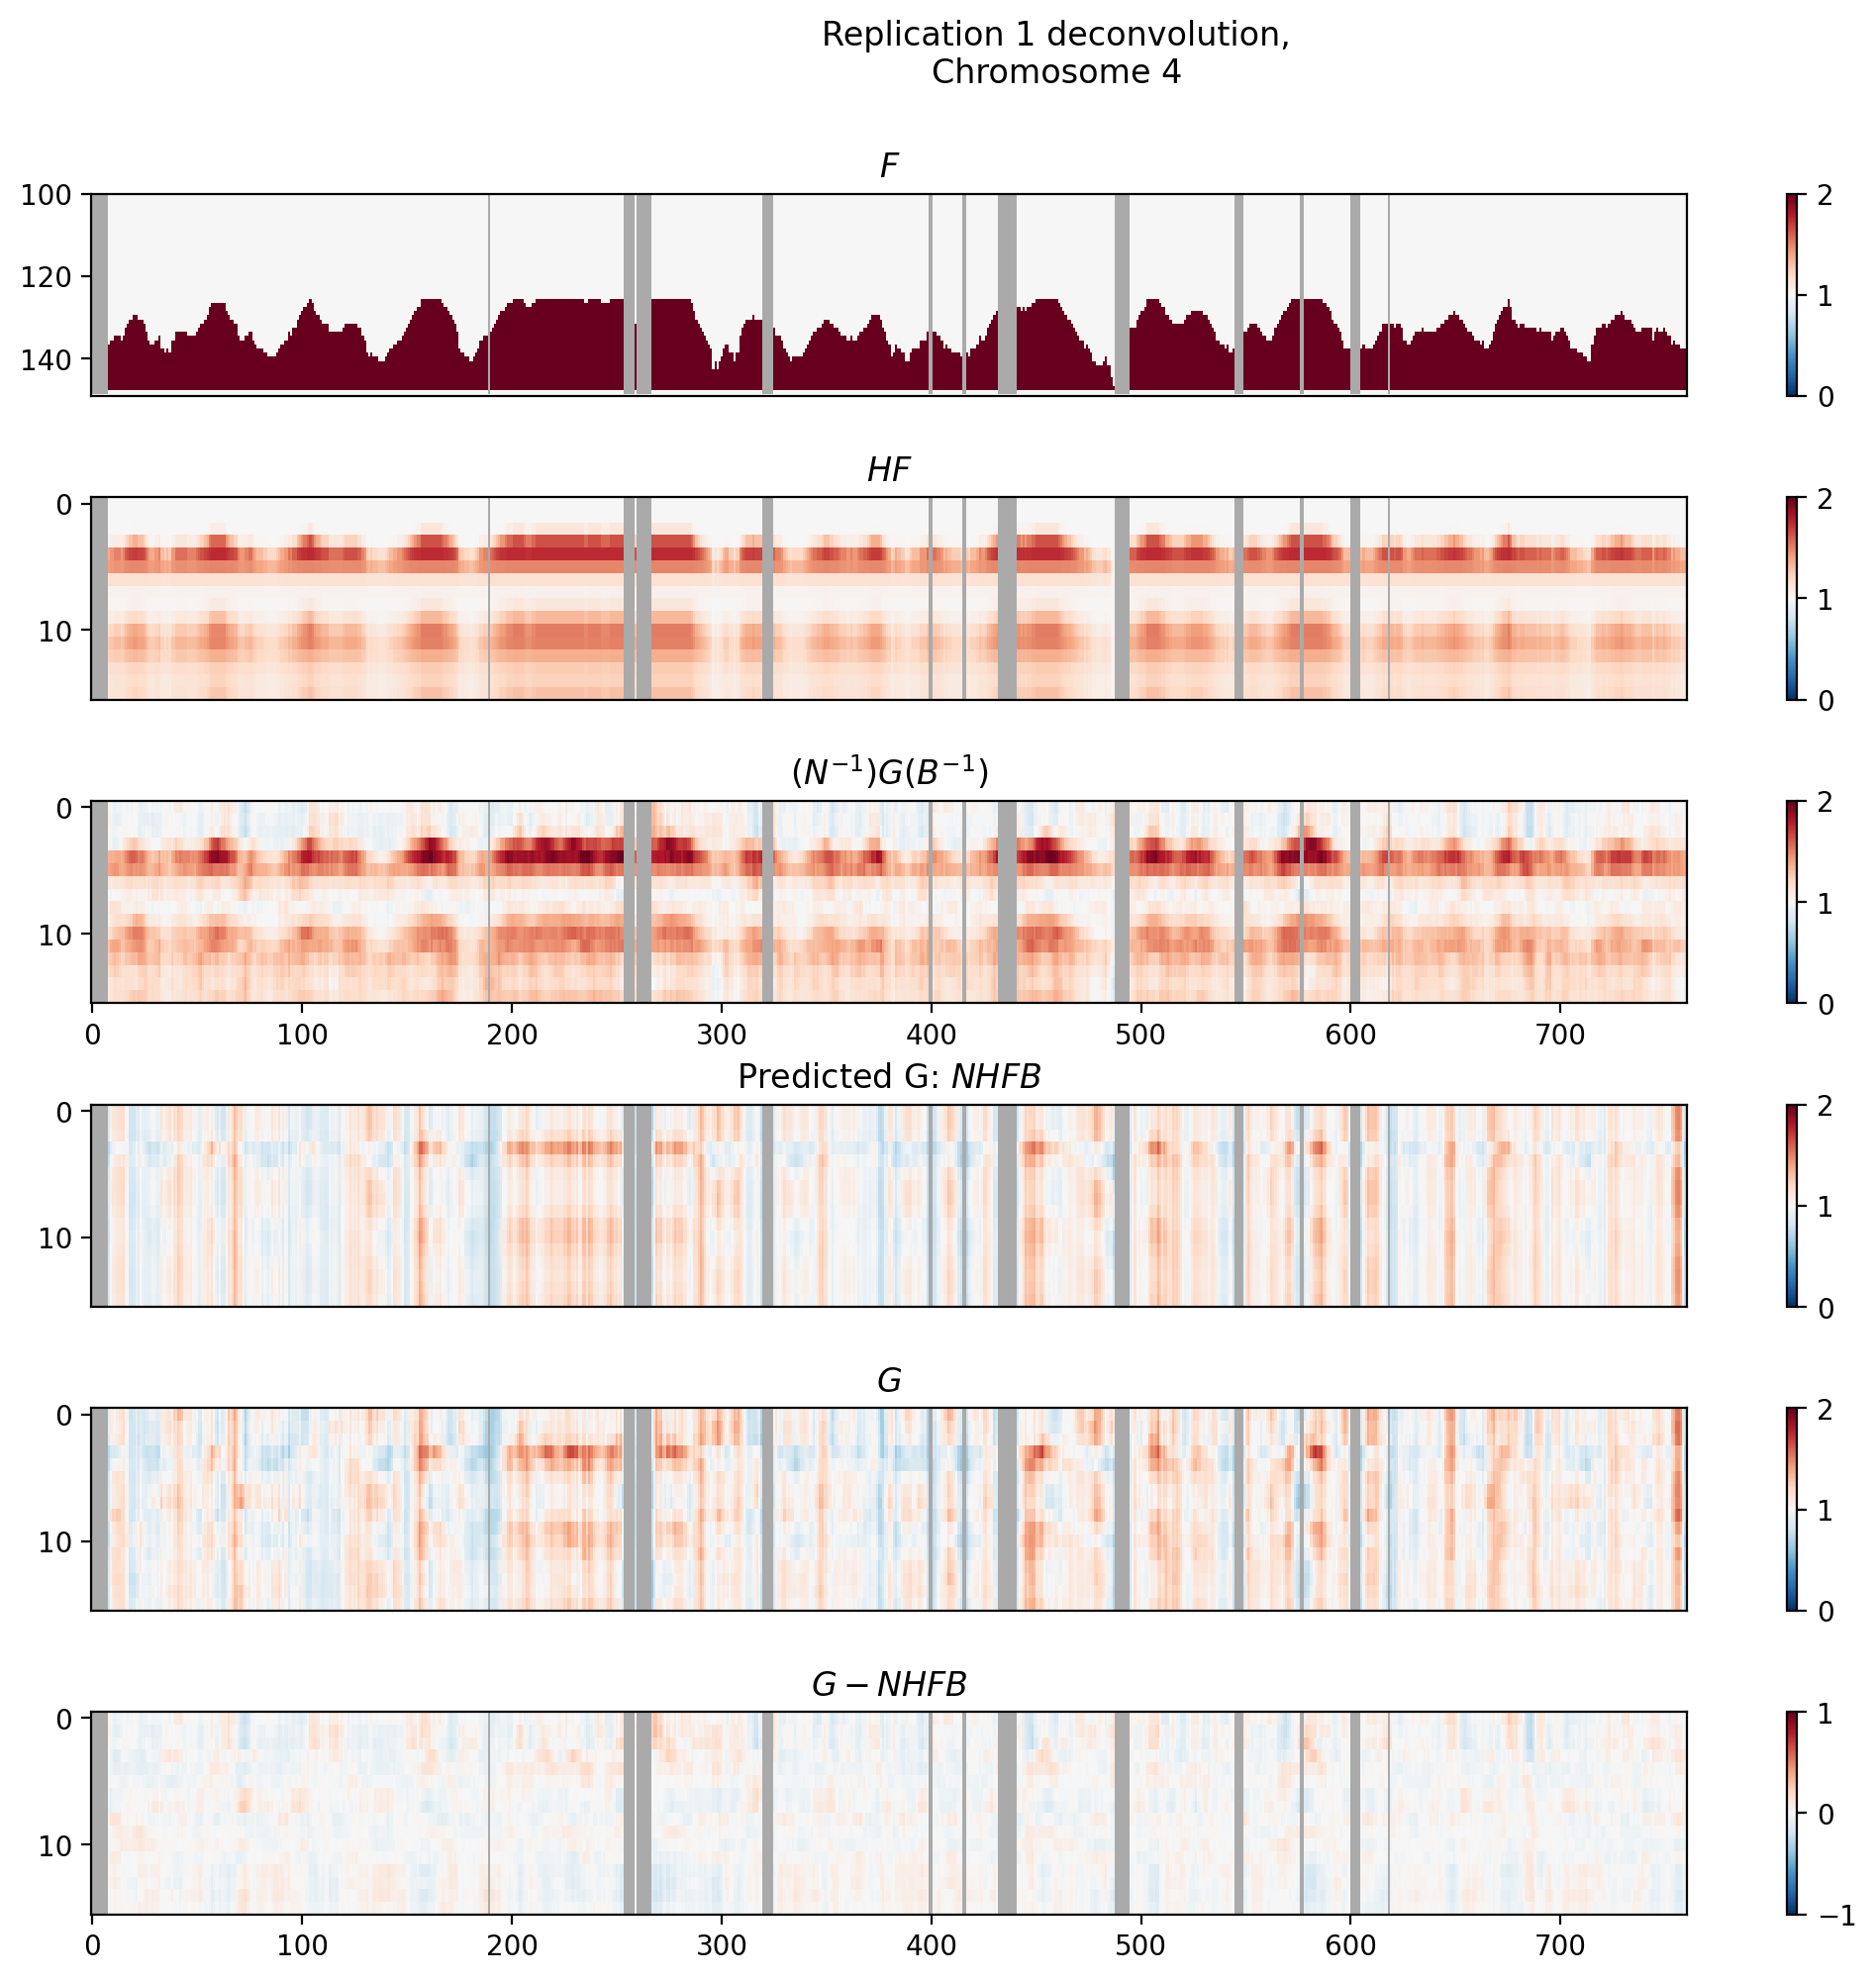

In [104]:
fig = replication_deconvolver.plot_heatmaps()